In [158]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [159]:
X_train = np.linspace(-1, 1, 20)

In [160]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [161]:
X_test = np.linspace(-1, 1, 20)

In [162]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

In [163]:
data = pd.DataFrame({'input': X, 'output': y})
print(data.head())

      input    output
0  0.097627  0.154783
1  0.430379  0.227049
2  0.205527  0.370844
3  0.089766 -0.082600
4 -0.152690 -0.102307


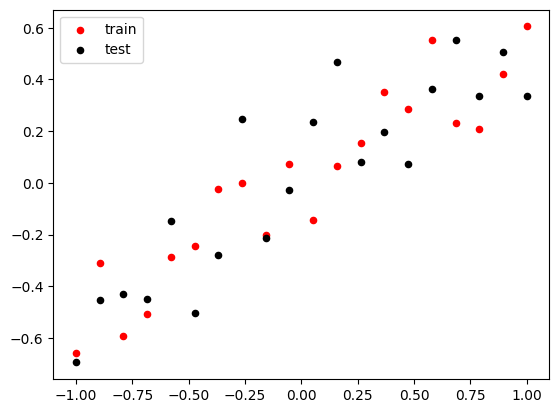

In [164]:
plt.scatter(X_train,y_train,color='red',label='train',s=20)
plt.scatter(X_test,y_test,color='black',label='test',s=20)
plt.legend()
plt.show()

In [165]:
import tensorflow
import keras

In [166]:
from keras.layers import Dense
from keras import Sequential

In [167]:
from keras.optimizers import Adam

In [168]:
model = Sequential()

In [169]:
model.add(Dense(128,activation='relu',input_dim=1))
model.add(Dense(128,activation="relu"))
model.add(Dense(1,activation="linear"))

D:\Deep_Learning\.venv_tf1\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [170]:
model.compile(loss="mse",optimizer=Adam(learning_rate=0.01),metrics=['mse'])

In [171]:
hist = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=200,verbose=False)

In [172]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


In [173]:
X_test.shape

(20,)

In [174]:
y_pred.shape

(20, 1)

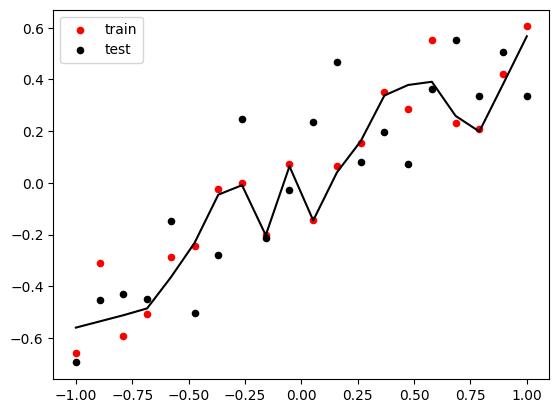

In [175]:
plt.scatter(X_train,y_train,c='red',s=20,label='train')
plt.scatter(X_test,y_test,c='black',s=20,label='test')
plt.plot(X_test,y_pred.ravel(),c='black')
plt.legend()
plt.show()

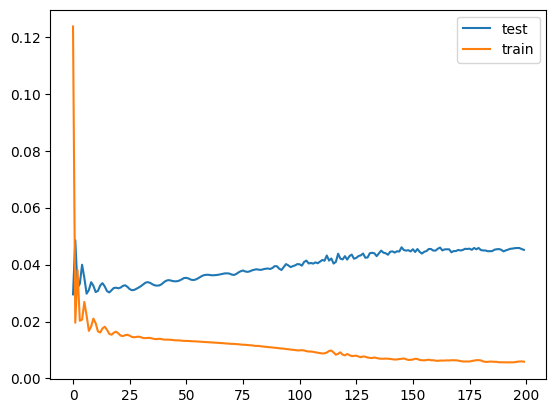

In [184]:
plt.plot(hist.history['val_loss'],label='test')
plt.plot(hist.history['loss'],label='train')
plt.legend()
plt.show()

### Overfitting from the above graph

# Dropouts

In [176]:
from keras.layers import Dropout

In [185]:
mod = Sequential()

In [186]:
mod.add(Dense(128,activation='relu',input_dim=1))
mod.add(Dropout(0.5))
mod.add(Dense(128,activation="relu"))
mod.add(Dropout(0.5))
mod.add(Dense(1,activation="linear"))

In [187]:
mod.compile(loss="mse",optimizer=Adam(learning_rate=0.01),metrics=['mse'])

In [188]:
history = mod.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=200,verbose=False)

In [189]:
y_predict_drop = mod.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


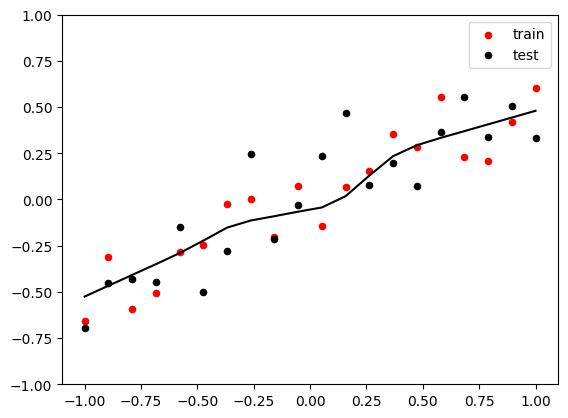

In [190]:
plt.scatter(X_train,y_train,c='red',s=20,label='train')
plt.scatter(X_test,y_test,c='black',s=20,label='test')
plt.plot(X_test,y_predict_drop.ravel(),c='black')
plt.ylim(-1,1)
plt.legend()
plt.show()

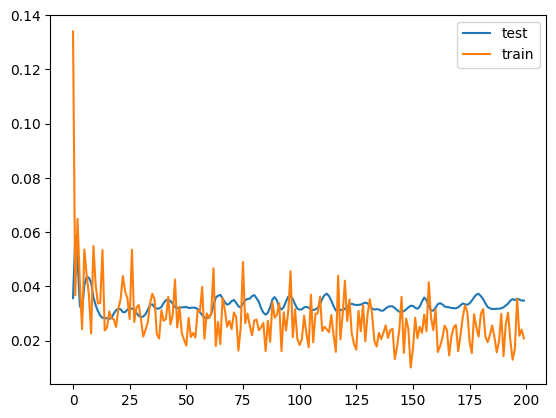

In [191]:
plt.plot(history.history['val_loss'],label='test')
plt.plot(history.history['loss'],label='train')
plt.legend()
plt.show()

### Overfitting decreases from the above graph